# v4_ge2/ge3/ge4 two-stage experiment with minsik_model

This notebook builds three two-stage experiments using only the `민식_model` training/evaluation/visualization code.

- Stage 1: BSD35k-CS v4 filtered subsets: `v4_ge2`, `v4_ge3`, `v4_ge4`
- Loss: `Proxy_Anchor + FocalLoss -> FocalLoss`
- Stage 2: BSD10k with `confidence == 1` excluded before train/val/test split
- Visualization: `민식_model/scripts/generate_tsne.py` and `민식_model/scripts/plot_fold_metrics.py`
- Dataset paths: use the actual local `./data/metadata` and `./data/features` folders

In [1]:
from pathlib import Path
import json
import os
import shutil
import subprocess
import sys
import time

import pandas as pd
import yaml

ROOT = Path.cwd().resolve()
if ROOT.name.lower() == "notebooks":
    ROOT = ROOT.parent
MINSIK_ROOT = ROOT / "민식_model" / "dcase2026-task1-training-pipeline"
SRC_ROOT = MINSIK_ROOT

if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

DATA_ROOT = ROOT / "data"
BSD10K_METADATA = DATA_ROOT / "metadata" / "BSD10k_metadata.csv"
BSD35K_METADATA = DATA_ROOT / "metadata" / "BSD35k-CS_metadata.csv"
BSD10K_AUDIO_DIR = DATA_ROOT / "features" / "clap_audio_embeddings"
BSD10K_TEXT_DIR = DATA_ROOT / "features" / "clap_text_embeddings"
BSD35K_AUDIO_DIR = DATA_ROOT / "features" / "BSD35k_clap_audio_embeddings"
BSD35K_TEXT_DIR = DATA_ROOT / "features" / "BSD35k-CS_clap_text_embeddings"
V4_PREDICTIONS = ROOT / "outputs" / "confidence_filter_v4" / "predictions" / "BSD35k-CS_filter_predictions_v4.csv"

GENERATED_ROOT = MINSIK_ROOT / "generated_v4_2stage"
GENERATED_METADATA_DIR = GENERATED_ROOT / "metadata"
GENERATED_FILTER_DIR = GENERATED_ROOT / "filter"
GENERATED_CONFIG_DIR = MINSIK_ROOT / "configs" / "generated_v4_2stage"
OUTPUT_ROOT = MINSIK_ROOT / "output"

for path in [GENERATED_METADATA_DIR, GENERATED_FILTER_DIR, GENERATED_CONFIG_DIR, OUTPUT_ROOT]:
    path.mkdir(parents=True, exist_ok=True)

required_paths = [
    MINSIK_ROOT,
    BSD10K_METADATA,
    BSD35K_METADATA,
    BSD10K_AUDIO_DIR,
    BSD10K_TEXT_DIR,
    BSD35K_AUDIO_DIR,
    BSD35K_TEXT_DIR,
    V4_PREDICTIONS,
]
missing = [str(p) for p in required_paths if not p.exists()]
if missing:
    raise FileNotFoundError("Missing required paths:\n" + "\n".join(missing))

print("ROOT:", ROOT)
print("MINSIK_ROOT:", MINSIK_ROOT)
print("Generated configs:", GENERATED_CONFIG_DIR)
print("Generated metadata/filter files:", GENERATED_ROOT)

ROOT: C:\Users\solok\Desktop\Dcase baseline
MINSIK_ROOT: C:\Users\solok\Desktop\Dcase baseline\민식_model\dcase2026-task1-training-pipeline
Generated configs: C:\Users\solok\Desktop\Dcase baseline\민식_model\dcase2026-task1-training-pipeline\configs\generated_v4_2stage
Generated metadata/filter files: C:\Users\solok\Desktop\Dcase baseline\민식_model\dcase2026-task1-training-pipeline\generated_v4_2stage


## 1. Build v4_ge2/v4_ge3/v4_ge4 BSD35k metadata files

`v4_35k_baseline모델.ipynb` used `predicted_confidence_score = 1 + 4 * v4_filter_score` and then thresholds `>= 2`, `>= 3`, `>= 4`. The same rule is used here, but the result is converted into metadata CSVs that `민식_model` can load through its existing dataset builder.

In [2]:
v4 = pd.read_csv(V4_PREDICTIONS)

required_v4_cols = {"sound_id", "class", "class_idx", "class_top", "v4_filter_score"}
missing_cols = sorted(required_v4_cols - set(v4.columns))
if missing_cols:
    raise ValueError(f"Missing columns in v4 prediction file: {missing_cols}")

v4["sound_id"] = v4["sound_id"].astype(str).str.strip()
v4["predicted_confidence_score"] = 1.0 + 4.0 * v4["v4_filter_score"].astype(float)

def embedding_exists(sound_id: str) -> bool:
    return (BSD35K_AUDIO_DIR / f"{sound_id}.npy").is_file() and (BSD35K_TEXT_DIR / f"{sound_id}.npy").is_file()

v4["has_embeddings"] = v4["sound_id"].map(embedding_exists)
usable = v4[v4["has_embeddings"]].copy().reset_index(drop=True)

metadata_cols = [
    "sound_id",
    "class",
    "class_idx",
    "class_top",
    "confidence",
    "uploader",
    "title",
    "tags",
    "description",
]

def make_subset_metadata(label: str, threshold: float) -> Path:
    subset = usable[usable["predicted_confidence_score"] >= threshold].copy().reset_index(drop=True)
    subset["confidence"] = subset["predicted_confidence_score"]
    for col in metadata_cols:
        if col not in subset.columns:
            subset[col] = ""
    out_path = GENERATED_METADATA_DIR / f"BSD35k-CS_v4_{label}_metadata.csv"
    subset[metadata_cols].to_csv(out_path, index=False)
    return out_path

v4_metadata_paths = {
    "v4_ge2": make_subset_metadata("ge2", 2.0),
    "v4_ge3": make_subset_metadata("ge3", 3.0),
    "v4_ge4": make_subset_metadata("ge4", 4.0),
}

subset_rows = []
for label, path in v4_metadata_paths.items():
    df = pd.read_csv(path)
    subset_rows.append({
        "subset": label,
        "metadata_csv": str(path),
        "samples": len(df),
        "classes": df["class"].nunique(),
    })

subset_summary = pd.DataFrame(subset_rows)
subset_summary.to_csv(GENERATED_ROOT / "v4_ge234_pretrain_metadata_summary.csv", index=False)
subset_summary

,subset,metadata_csv,samples,classes
0,v4_ge2,C:\Users\solok\Desktop\Dcase baseline\민식_model...,23851,23
1,v4_ge3,C:\Users\solok\Desktop\Dcase baseline\민식_model...,15566,23
2,v4_ge4,C:\Users\solok\Desktop\Dcase baseline\민식_model...,7633,23


## 2. Build BSD10k confidence==1 exclusion file

`민식_model` filtering expects a review CSV with `sound_id,action,reason`. This stage1 filter is applied before the finetune train/val/test split, so confidence-1 rows are excluded from training, validation, and final test.

In [3]:
bsd10k_meta = pd.read_csv(BSD10K_METADATA)
bsd10k_meta["sound_id"] = bsd10k_meta["sound_id"].astype(str).str.strip()
confidence1 = bsd10k_meta[bsd10k_meta["confidence"].astype(str).str.strip() == "1"].copy()

confidence1_review_csv = GENERATED_FILTER_DIR / "BSD10k_confidence1_exclude_review_actions.csv"
pd.DataFrame({
    "sound_id": confidence1["sound_id"],
    "action": "exclude",
    "reason": "BSD10k confidence==1 excluded for v4_ge234 two-stage finetune/eval/test",
}).to_csv(confidence1_review_csv, index=False)

print("BSD10k full rows:", len(bsd10k_meta))
print("BSD10k confidence==1 excluded rows:", len(confidence1))
print("review csv:", confidence1_review_csv)

BSD10k full rows: 10956
BSD10k confidence==1 excluded rows: 106
review csv: C:\Users\solok\Desktop\Dcase baseline\민식_model\dcase2026-task1-training-pipeline\generated_v4_2stage\filter\BSD10k_confidence1_exclude_review_actions.csv


## 3. Generate two-stage configs

Each generated config keeps the same method:

- pretrain: `run_mode=dual_head`, `Proxy_Anchor + FocalLoss`, weights `1.0 + 1.0`
- finetune: `run_mode=standard`, `FocalLoss`, `proxy_loss=null`, `proxy_weight=0.0`
- scheduler: cosine, hF1 early stopping
- mode: `both` only

In [4]:
def make_config(label: str, pretrain_metadata_csv: Path) -> dict:
    run_name = f"generated_v4_2stage/{label}_proxy_focal_to_focal_conf1_excluded"
    pretrain_dataset_name = f"BSD35k-CS-{label}"
    return {
        "strategy": "two_stage",
        "pretrain_dataset": pretrain_dataset_name,
        "finetune_dataset": "BSD10k-v1.2",
        "datasets": {
            "BSD10k-v1.2": {
                "metadata_csv": str(BSD10K_METADATA),
                "audio_emb_folder": str(BSD10K_AUDIO_DIR),
                "text_emb_folder": str(BSD10K_TEXT_DIR),
            },
            pretrain_dataset_name: {
                "metadata_csv": str(pretrain_metadata_csv),
                "audio_emb_folder": str(BSD35K_AUDIO_DIR),
                "text_emb_folder": str(BSD35K_TEXT_DIR),
            },
        },
        "paths": {
            "data_root": str(DATA_ROOT),
            "processed_basename": "processed_dataset.csv",
        },
        "output": {
            "root": str(OUTPUT_ROOT),
            "run_dir": run_name,
            "pretrain_dir": run_name,
        },
        "model": {
            "name": "base_classifier_proxy_anchor_simple",
            "embedding_dim": 128,
        },
        "artifact_names": {
            "processed_dataset_csv": "processed_dataset.csv",
            "class_dict_json": "class_dict.json",
            "top_class_dict_json": "top_class_dict.json",
            "top_class_subclass_dict_json": "top_class_subclass_dict.json",
        },
        "trainer": {
            "mode": "both",
        },
        "pretrain": {
            "enabled": True,
            "training": {
                "run_mode": "dual_head",
                "batch_size": 64,
                "num_epochs": 50,
                "lr": 0.0005,
                "scheduler_type": "cosine",
                "scheduler_params": {"t_max": 25},
                "patience": 5,
                "early_stopping_metric": "hF1",
                "proxy_weight": 1.0,
                "classification_weight": 1.0,
                "proxy_loss": "Proxy_Anchor",
                "proxy_loss_params": {"mrg": 0.1, "alpha": 32},
                "classifier_loss": "FocalLoss",
                "classifier_loss_params": {"gamma": 2.0, "alpha": 0.25},
            },
        },
        "finetune": {
            "enabled": True,
            "k_folds": 5,
            "training": {
                "run_mode": "standard",
                "batch_size": 64,
                "num_epochs": 50,
                "lr": 0.0005,
                "scheduler_type": "cosine",
                "scheduler_params": {"t_max": 25},
                "patience": 10,
                "early_stopping_metric": "hF1",
                "proxy_weight": 0.0,
                "classification_weight": 1.0,
                "proxy_loss": None,
                "proxy_loss_params": {},
                "classifier_loss": "FocalLoss",
                "classifier_loss_params": {"gamma": 2.0, "alpha": 0.25},
                "k_folds": 5,
            },
        },
        "evaluation": {
            "batch_size": 128,
            "num_workers": 4,
            "device": "auto",
            "save_manifest": True,
        },
        "evaluator_config": {
            "type": "classification",
        },
        "filtering": {
            "stage1": {
                "enabled": True,
                "review_actions_csv": str(confidence1_review_csv),
                "report_dir": str(OUTPUT_ROOT / "filter_reports"),
                "report_name_template": "{tag}_stage1_filter_report.json",
                "apply_to": "all",
            },
            "stage2": {
                "enabled": False,
                "review_actions_csv": None,
                "report_dir": str(OUTPUT_ROOT / "filter_reports"),
                "report_name_template": "{tag}_fold_{fold}_{split}_stage2_filter_report.json",
                "apply_to": "train",
            },
        },
        "embeddings": {
            "enabled": False,
            "extractors": [],
            "audio_dirname": "audio_embeddings",
            "text_dirname": "text_embeddings",
        },
        "logging": {
            "run_log_csv": "run_log.csv",
        },
        "repro": {
            "seed": 1821,
        },
    }

config_paths = {}
for label, meta_path in v4_metadata_paths.items():
    cfg = make_config(label, meta_path)
    cfg_path = GENERATED_CONFIG_DIR / f"{label}_proxy_focal_to_focal_conf1_excluded.yaml"
    cfg_path.write_text(yaml.safe_dump(cfg, sort_keys=False, allow_unicode=True), encoding="utf-8")
    config_paths[label] = cfg_path

pd.DataFrame([{"subset": k, "config": str(v)} for k, v in config_paths.items()])

,subset,config
0,v4_ge2,C:\Users\solok\Desktop\Dcase baseline\민식_model...
1,v4_ge3,C:\Users\solok\Desktop\Dcase baseline\민식_model...
2,v4_ge4,C:\Users\solok\Desktop\Dcase baseline\민식_model...


## 4. Run training

Set `RUN_TRAINING = True` when you want to launch all three experiments. This directly calls `민식_model`'s `PretrainTrainer` and `FinetuneTrainer`; no outside model/training code is used.

In [5]:
RUN_TRAINING = True
RESET_EXISTING_OUTPUTS = False

def run_two_stage_config(label: str, cfg_path: Path) -> None:
    from src.trainers.pretrain_trainer import PretrainTrainer
    from src.trainers.finetune_trainer import FinetuneTrainer

    with open(cfg_path, "r", encoding="utf-8") as f:
        config = yaml.safe_load(f) or {}

    run_output_dir = Path(config["output"]["root"]) / config["output"]["run_dir"] / config["model"]["name"]
    if RESET_EXISTING_OUTPUTS and run_output_dir.exists():
        shutil.rmtree(run_output_dir)

    print("=" * 100)
    print(f"Running {label}: {cfg_path}")
    print("Output:", run_output_dir)
    print("=" * 100)

    pretrainer = PretrainTrainer(config=config)
    pretrainer.run()

    finetuner = FinetuneTrainer(config=config)
    finetuner.run()

if RUN_TRAINING:
    for label in ["v4_ge2", "v4_ge3", "v4_ge4"]:
        run_two_stage_config(label, config_paths[label])
else:
    print("RUN_TRAINING is False. Set it to True to run v4_ge2/v4_ge3/v4_ge4 two-stage training.")

Running v4_ge2: C:\Users\solok\Desktop\Dcase baseline\민식_model\dcase2026-task1-training-pipeline\configs\generated_v4_2stage\v4_ge2_proxy_focal_to_focal_conf1_excluded.yaml
Output: C:\Users\solok\Desktop\Dcase baseline\민식_model\dcase2026-task1-training-pipeline\output\generated_v4_2stage\v4_ge2_proxy_focal_to_focal_conf1_excluded\base_classifier_proxy_anchor_simple
Examining original data from BSD35k-CS-v4_ge2:
  Total rows: 23851
  Unique classes: 23
After filtering: 23851
Saved class dictionary to C:\Users\solok\Desktop\Dcase baseline\민식_model\dcase2026-task1-training-pipeline\output\generated_v4_2stage/v4_ge2_proxy_focal_to_focal_conf1_excluded\base_classifier_proxy_anchor_simple\class_dict.json
Saved top class dictionary to C:\Users\solok\Desktop\Dcase baseline\민식_model\dcase2026-task1-training-pipeline\output\generated_v4_2stage/v4_ge2_proxy_focal_to_focal_conf1_excluded\base_classifier_proxy_anchor_simple\top_class_dict.json
Saved top class subclass dictionary to C:\Users\solok\D

## 5. Run minsik_model visualization scripts

Set `RUN_VISUALIZATION = True` after training finishes. This calls the existing `민식_model` visualization scripts as-is.

In [6]:
RUN_VISUALIZATION = False

def model_output_root_from_config(cfg_path: Path) -> Path:
    config = yaml.safe_load(cfg_path.read_text(encoding="utf-8")) or {}
    return Path(config["output"]["root"]) / config["output"]["run_dir"] / config["model"]["name"]

def run_minsik_visualizations(label: str, cfg_path: Path) -> None:
    model_output = model_output_root_from_config(cfg_path)

    tsne_cmd = [
        sys.executable,
        "scripts/generate_tsne.py",
        "--config",
        str(cfg_path),
        "--stages",
        "finetune,pretrain",
    ]
    print("Running:", " ".join(tsne_cmd))
    subprocess.run(tsne_cmd, cwd=MINSIK_ROOT, check=True)

    plot_cmd = [
        sys.executable,
        "scripts/plot_fold_metrics.py",
        "--model_output",
        str(model_output),
        "--mode",
        "both",
    ]
    print("Running:", " ".join(plot_cmd))
    subprocess.run(plot_cmd, cwd=MINSIK_ROOT, check=True)

if RUN_VISUALIZATION:
    for label in ["v4_ge2", "v4_ge3", "v4_ge4"]:
        run_minsik_visualizations(label, config_paths[label])
else:
    print("RUN_VISUALIZATION is False. Set it to True after training completes.")

RUN_VISUALIZATION is False. Set it to True after training completes.


## 6. Collect result summary

This cell only reads artifacts created by `민식_model`: `summary_metrics.json`, fold-level `metrics.json`, and generated split/filter files.

In [7]:
def collect_results() -> pd.DataFrame:
    rows = []
    for label, cfg_path in config_paths.items():
        model_output = model_output_root_from_config(cfg_path)
        mode_dir = model_output / "both"
        for fold_dir in sorted(mode_dir.glob("fold_*")):
            metrics_path = fold_dir / "metrics.json"
            if not metrics_path.is_file():
                continue
            metrics = json.loads(metrics_path.read_text(encoding="utf-8"))
            rows.append({
                "subset": label,
                "fold": fold_dir.name,
                "accuracy": metrics.get("accuracy"),
                "top_accuracy": metrics.get("top_accuracy"),
                "macro_accuracy": metrics.get("macro_accuracy"),
                "hierarchical_accuracy": metrics.get("hierarchical_accuracy"),
                "hierarchical_f1": metrics.get("hierarchical_f1", metrics.get("hierarchical_f1-score")),
                "model_output": str(model_output),
            })
    return pd.DataFrame(rows)

results = collect_results()
if len(results):
    summary = results.groupby("subset", as_index=False).agg({
        "accuracy": ["mean", "std"],
        "top_accuracy": ["mean", "std"],
        "hierarchical_accuracy": ["mean", "std"],
        "hierarchical_f1": ["mean", "std"],
    })
    summary.to_csv(GENERATED_ROOT / "v4_ge234_two_stage_result_summary.csv", index=False)
    display(results)
    display(summary)
else:
    print("No fold metrics found yet. Run training first.")

,subset,fold,accuracy,top_accuracy,macro_accuracy,hierarchical_accuracy,hierarchical_f1,model_output
0,v4_ge2,fold_0,80.611314,90.328467,75.398237,81.018900,79.925105,C:\Users\solok\Desktop\Dcase baseline\민식_model...
1,v4_ge2,fold_1,79.972628,89.187956,75.082132,80.136487,78.572477,C:\Users\solok\Desktop\Dcase baseline\민식_model...
2,v4_ge2,fold_2,80.337591,89.552920,75.008913,80.442573,78.851030,C:\Users\solok\Desktop\Dcase baseline\민식_model...
3,v4_ge2,fold_3,80.018248,89.963504,74.409104,80.159273,78.751638,C:\Users\solok\Desktop\Dcase baseline\민식_model...
4,v4_ge2,fold_4,80.018248,89.096715,75.393660,80.557547,78.710010,C:\Users\solok\Desktop\Dcase baseline\민식_model...
5,v4_ge3,fold_0,80.839416,90.100365,75.852356,80.915583,79.854442,C:\Users\solok\Desktop\Dcase baseline\민식_model...
6,v4_ge3,fold_1,80.565693,89.552920,75.379741,80.362515,79.485539,C:\Users\solok\Desktop\Dcase baseline\민식_model...
7,v4_ge3,fold_2,81.295620,90.967153,76.105231,81.614795,80.320085,C:\Users\solok\Desktop\Dcase baseline\민식_model...
8,v4_ge3,fold_3,80.018248,89.416058,74.717089,80.166198,78.850802,C:\Users\solok\Desktop\Dcase baseline\민식_model...
9,v4_ge3,fold_4,80.383212,89.826642,74.410856,79.953752,78.957484,C:\Users\solok\Desktop\Dcase baseline\민식_model...


subset   accuracy           top_accuracy           hierarchical_accuracy  \
                mean       std         mean       std                  mean   
0  v4_ge2  80.191606  0.276371    89.625912  0.520753             80.462956   
1  v4_ge3  80.620438  0.481074    89.972628  0.614946             80.602568   
2  v4_ge4  80.729927  0.169472    89.927007  0.348033             80.513934   

            hierarchical_f1            
        std            mean       std  
0  0.359598       78.962052  0.547578  
1  0.669251       79.493671  0.615215  
2  0.190188       79.289058  0.328480

In [8]:
import subprocess

for label, cfg_path in config_paths.items():
    print(f"\n{'='*60}")
    print(f"Generating t-SNE: {label}")
    print(f"{'='*60}")
    result = subprocess.run(
        [
            sys.executable,
            "scripts/generate_tsne.py",
            "--config", str(cfg_path),
            "--stages", "finetune,pretrain",
        ],
        cwd=MINSIK_ROOT,
        check=True,
    )
print("\nt-SNE 생성 완료")



Generating t-SNE: v4_ge2

Generating t-SNE: v4_ge3

Generating t-SNE: v4_ge4

t-SNE 생성 완료


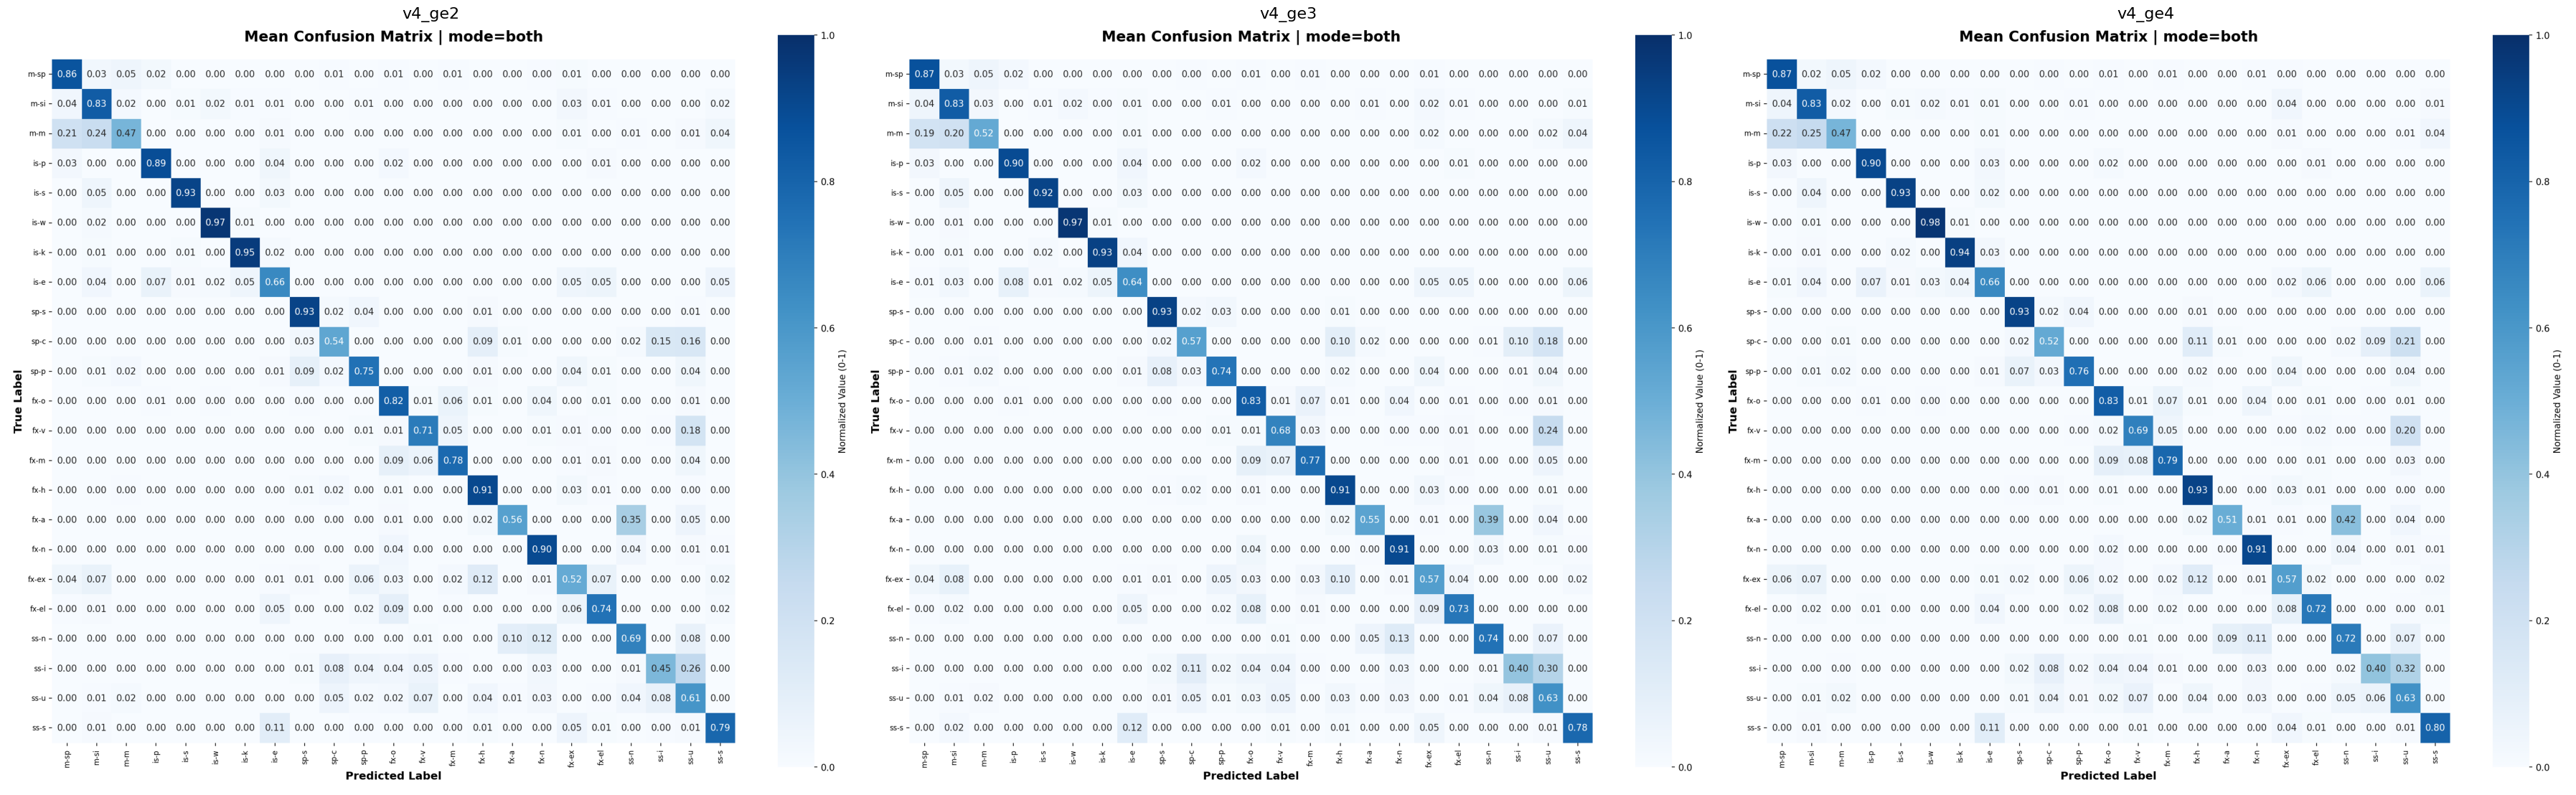

In [9]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

fig, axes = plt.subplots(1, 3, figsize=(36, 12))

for ax, (label, cfg_path) in zip(axes, config_paths.items()):
    model_output = model_output_root_from_config(cfg_path)
    cm_path = model_output / "both" / "confusion_matrix_mean.png"
    if cm_path.exists():
        img = mpimg.imread(str(cm_path))
        ax.imshow(img)
        ax.set_title(label, fontsize=16)
        ax.axis("off")
    else:
        ax.text(0.5, 0.5, f"{label}\n파일 없음", ha="center", va="center")
        ax.axis("off")

plt.tight_layout()
plt.savefig(str(GENERATED_ROOT / "ge234_confusion_matrix_compare.png"), dpi=150, bbox_inches="tight")
plt.show()
